# Unsupervised SVD Analysis of Uber Pickup Data

This notebook performs a Singular Value Decomposition (SVD) on a New York City Uber rides dataset.  
It will:

1. Load and inspect the raw data  
2. Extract and preprocess numeric features  
3. Compute the full SVD (`X = U S Vᵀ`)  
4. Project the data onto the top two components and visualize  
5. Identify the most extreme rides along the first principal component  


In [3]:
# Cell 2: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Cell 3: Load CSV and show first rows
df = pd.read_csv("/Users/pbat/Projects/cmor438/data/uber.csv")
df.head()


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
# Cell 4: Convert pickup_datetime, extract hour
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df[['pickup_datetime','hour']].head()


,pickup_datetime,hour
0,2015-05-07 19:52:06+00:00,19
1,2009-07-17 20:04:56+00:00,20
2,2009-08-24 21:45:00+00:00,21
3,2009-06-26 08:22:21+00:00,8
4,2014-08-28 17:47:00+00:00,17


In [7]:
# Cell 5: Choose numeric features and drop missing
features = [
    'fare_amount',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'passenger_count',
    'hour'
]
X = df[features].dropna()
print(f"Rows after dropna: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")


Rows after dropna: 199999
Number of features: 7


In [8]:
# Cell 6: Center data and run full SVD
X_centered = X - X.mean()
X_mat = X_centered.values
U, S, Vt = np.linalg.svd(X_mat, full_matrices=False)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Top 10 singular values:", S[:10])


U shape: (199999, 7)
S shape: (7,)
Vt shape: (7, 7)
Top 10 singular values: [8492.8914707  4428.65649413 2912.62303951 2342.813075   1785.22249638
  964.53868837  619.73259522]


In [9]:
# Cell 7: Project onto top 2 components
X_proj = X_mat.dot(Vt.T[:, :2])
print("First 5 rows of 2D projection:")
X_proj[:5]


First 5 rows of 2D projection:


array([[-2.38684088, -3.98003973],
       [-2.38331077, -3.80508715],
       [-2.34047761,  1.36809027],
       [-2.42543054, -5.90211876],
       [-2.28164499,  4.57230452]])

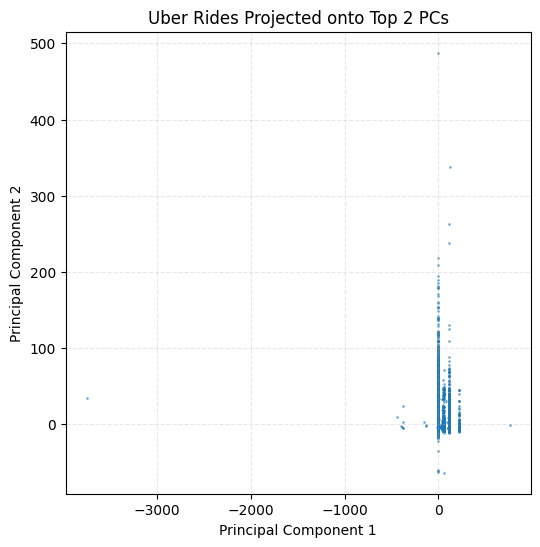

In [10]:
# Cell 8: Plot the 2D embedding
plt.figure(figsize=(6,6))
plt.scatter(X_proj[:,0], X_proj[:,1], s=1, alpha=0.5)
plt.title('Uber Rides Projected onto Top 2 PCs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


In [11]:
# Cell 9: Find top 3 rides by |PC1|
idx_sorted_by_pc1 = np.argsort(np.abs(X_proj[:, 0]))[::-1]
top3_idx = idx_sorted_by_pc1[:3]
print("Top 3 rides by |PC1| indices:", top3_idx)
print("\nTheir raw feature values:")
X.iloc[top3_idx]


Top 3 rides by |PC1| indices: [75851 91421 32549]

Their raw feature values:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour
75851,15.7,-1340.648410,1644.421482,-3356.666300,872.697628,1,0
91422,16.1,57.418457,1292.016128,1153.572603,-881.985513,1,13
32549,15.7,-74.016055,40.715155,-737.916665,40.697862,2,10
